100%|██████████| 9.91M/9.91M [00:01<00:00, 5.81MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.92MB/s]


Epoch 1, Loss: 11722699.09
Epoch 2, Loss: 10227926.33
Epoch 3, Loss: 9927884.37


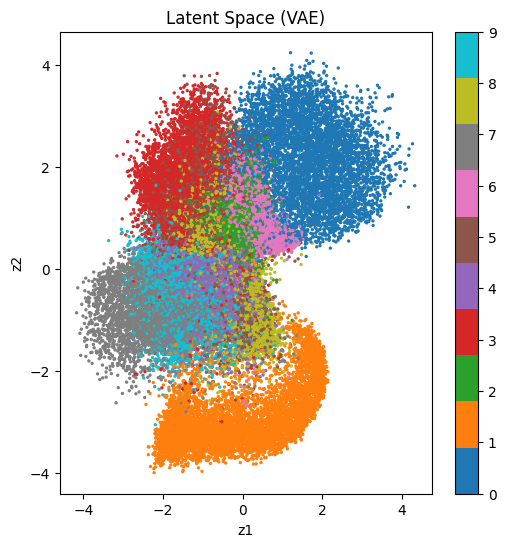

In [1]:
# ==============================
# Install (if needed)
# ==============================
!pip install torch torchvision matplotlib -q

# ==============================
# Imports
# ==============================
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================
# Load MNIST dataset (online)
# ==============================
transform = transforms.ToTensor()

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True)

# ==============================
# VAE Model
# ==============================
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(28*28, 256)
        self.fc_mu = nn.Linear(256, 2)       # latent dim = 2 (for visualization)
        self.fc_logvar = nn.Linear(256, 2)

        # Decoder
        self.fc2 = nn.Linear(2, 256)
        self.fc3 = nn.Linear(256, 28*28)

    def encode(self, x):
        x = torch.relu(self.fc1(x))
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        z = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE().to(device)

# ==============================
# Loss Function
# ==============================
def loss_fn(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# ==============================
# Training
# ==============================
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(3):   # small epochs for fast run
    total_loss = 0
    for x, _ in train_loader:
        x = x.view(-1, 28*28).to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = loss_fn(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

# ==============================
# Latent Space Visualization
# ==============================
model.eval()
zs = []
labels = []

with torch.no_grad():
    for x, y in train_loader:
        x = x.view(-1, 28*28).to(device)
        mu, _ = model.encode(x)
        zs.append(mu.cpu())
        labels.append(y)

zs = torch.cat(zs)
labels = torch.cat(labels)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(zs[:,0], zs[:,1], c=labels, cmap="tab10", s=2)
plt.colorbar()
plt.title("Latent Space (VAE)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()